In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader

# Add project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"Project root: {project_root}")
print("Libraries imported successfully.")

Project root: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel
Libraries imported successfully.


In [4]:
data_root = project_root / "data" / "raw" / "OpportunityUCIDataset"
dataset_dir = data_root / "dataset"

# ── Load column names ──
col_names_path = dataset_dir / "column_names.txt"
with open(col_names_path, "r") as f:
    raw_lines = f.readlines()

# Parse column names: lines look like "Column: N  <name>"
column_names = []
for line in raw_lines:
    line = line.strip()
    if line and not line.startswith("#") and "Column:" in line:
        # Extract name after the column number
        parts = line.split()
        # Find index after the number
        idx = parts.index("Column:") if "Column:" in parts else 0
        name = "_".join(parts[idx+2:])  # everything after "Column: N"
        column_names.append(name)

print(f"Parsed {len(column_names)} column names from column_names.txt")

# If parsing didn't work well, fall back to numbered columns
# The Opportunity dataset has 243 sensor columns + timestamp + label columns = 249 total
# We'll verify after loading a file

# ── Load label legend ──
label_path = dataset_dir / "label_legend.txt"
with open(label_path, "r") as f:
    label_lines = f.readlines()

print("\n--- Label Legend ---")
for line in label_lines[:30]:
    print(line.strip())

Parsed 250 column names from column_names.txt

--- Label Legend ---
Unique index   -   Track name   -   Label name

1   -   Locomotion   -   Stand
2   -   Locomotion   -   Walk
4   -   Locomotion   -   Sit
5   -   Locomotion   -   Lie
101   -   HL_Activity   -   Relaxing
102   -   HL_Activity   -   Coffee time
103   -   HL_Activity   -   Early morning
104   -   HL_Activity   -   Cleanup
105   -   HL_Activity   -   Sandwich time
201   -   LL_Left_Arm   -   unlock
202   -   LL_Left_Arm   -   stir
203   -   LL_Left_Arm   -   lock
204   -   LL_Left_Arm   -   close
205   -   LL_Left_Arm   -   reach
206   -   LL_Left_Arm   -   open
207   -   LL_Left_Arm   -   sip
208   -   LL_Left_Arm   -   clean
209   -   LL_Left_Arm   -   bite
210   -   LL_Left_Arm   -   cut
211   -   LL_Left_Arm   -   spread
212   -   LL_Left_Arm   -   release
213   -   LL_Left_Arm   -   move
301   -   LL_Left_Arm_Object   -   Bottle
302   -   LL_Left_Arm_Object   -   Salami
303   -   LL_Left_Arm_Object   -   Bread
304   

In [5]:
# Load one file to understand structure
sample_file = dataset_dir / "S1-ADL1.dat"
sample_df = pd.read_csv(sample_file, sep=r'\s+', header=None)

print(f"Sample file: S1-ADL1.dat")
print(f"Shape: {sample_df.shape}")
print(f"Columns: {sample_df.columns.tolist()[:10]}...  (total: {sample_df.shape[1]})")
print(f"\nFirst 5 rows:")
sample_df.head()

Sample file: S1-ADL1.dat
Shape: (51116, 250)
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...  (total: 250)

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,240,241,242,243,244,245,246,247,248,249
0,0,87.0,975.0,-287.0,11.0,1001.0,163.0,95.0,975.0,152.0,...,5789.0,2907.0,1447.0,0,0,0,0,0,0,0
1,33,124.0,978.0,-389.0,-7.0,1014.0,199.0,124.0,968.0,123.0,...,5789.0,2908.0,1443.0,0,0,0,0,0,0,0
2,67,102.0,996.0,-440.0,-49.0,1024.0,193.0,127.0,1001.0,113.0,...,5789.0,2910.0,1440.0,0,0,0,0,0,0,0
3,100,59.0,861.0,-384.0,-9.0,1023.0,202.0,110.0,1007.0,106.0,...,5789.0,2912.0,1440.0,0,0,0,0,0,0,0
4,133,119.0,946.0,-426.0,-22.0,1026.0,188.0,98.0,1001.0,92.0,...,5791.0,2915.0,1442.0,0,0,0,0,0,0,0


In [6]:
"""
Opportunity dataset has 250 columns (0-indexed):
  Col 0: MILLISEC (timestamp)
  Col 1-134: Body-worn sensors (accelerometers, gyroscopes, magnetic sensors)
  Col 135-242: Object sensors (on objects in the environment)
  Col 243: Locomotion label  (stand, walk, sit, lie)
  Col 244: HL_Activity label (high-level: relaxing, coffee time, early morning, cleanup, sandwich time)
  Col 245-249: ML_Both_Arms, ML_Left_Arm, ML_Left_Arm_Object, ML_Right_Arm, ML_Right_Arm_Object
  
For this project we focus on:
  - Locomotion task (col 243) — 4-class + Null (0)
  - OR gesture recognition (cols 245-249)
  
We'll use body-worn sensors (cols 1-134) as features for a cleaner setup.
"""

NUM_TOTAL_COLS = sample_df.shape[1]
print(f"Total columns in dataset: {NUM_TOTAL_COLS}")

# Define label columns based on standard Opportunity benchmark
# Column indices (0-based)
TIMESTAMP_COL = 0
LOCOMOTION_LABEL_COL = 243   # Locomotion label
HL_ACTIVITY_LABEL_COL = 244  # High-level activity

# Mid-level gesture labels
ML_BOTH_ARMS_COL = 245
ML_LEFT_ARM_COL = 246
ML_LEFT_ARM_OBJ_COL = 247
ML_RIGHT_ARM_COL = 248
ML_RIGHT_ARM_OBJ_COL = 249

# Feature columns: all sensor readings (cols 1-242)
SENSOR_COLS = list(range(1, 243))

# Body-worn sensor columns only (cols 1-134) — used in the benchmark
BODY_SENSOR_COLS = list(range(1, 135))

# Generate column names
col_names_full = ['MILLISEC'] + [f'sensor_{i}' for i in range(1, 243)] + \
                 ['locomotion', 'HL_activity', 
                  'ML_both_arms', 'ML_left_arm', 'ML_left_arm_obj',
                  'ML_right_arm', 'ML_right_arm_obj']

if NUM_TOTAL_COLS == len(col_names_full):
    print(f"✅ Column count matches: {NUM_TOTAL_COLS}")
else:
    print(f"⚠️ Expected {len(col_names_full)} columns, got {NUM_TOTAL_COLS}")
    # Adjust if needed
    col_names_full = [f'col_{i}' for i in range(NUM_TOTAL_COLS)]

print(f"Sensor columns: {len(SENSOR_COLS)}")
print(f"Body-worn sensor columns: {len(BODY_SENSOR_COLS)}")

Total columns in dataset: 250
✅ Column count matches: 250
Sensor columns: 242
Body-worn sensor columns: 134


In [7]:
"""
Opportunity benchmark split (from prepareData.m):
  Training: S1-ADL1..3 + S1-Drill, S2-ADL1..3 + S2-Drill, S3-ADL1..3 + S3-Drill, S4-ADL1..3 + S4-Drill  
  Testing:  S1-ADL4..5, S2-ADL4..5, S3-ADL4..5, S4-ADL4..5

Standard benchmark uses S1-S4 for training (ADL1-3 + Drill) and ADL4-5 for testing.
We'll follow this convention.
"""

SUBJECTS = [1, 2, 3, 4]
TRAIN_RUNS = ['ADL1', 'ADL2', 'ADL3', 'Drill']
TEST_RUNS = ['ADL4', 'ADL5']

def load_opportunity_file(filepath, col_names):
    """Load a single .dat file"""
    df = pd.read_csv(filepath, sep=r'\s+', header=None)
    if len(col_names) == df.shape[1]:
        df.columns = col_names
    return df

def load_opportunity_split(subjects, runs, dataset_dir, col_names):
    """Load multiple files for a given split"""
    dfs = []
    for subj in subjects:
        for run in runs:
            fname = f"S{subj}-{run}.dat"
            fpath = dataset_dir / fname
            if fpath.exists():
                df = load_opportunity_file(fpath, col_names)
                df['subject'] = subj
                df['run'] = run
                dfs.append(df)
                print(f"  Loaded {fname}: {df.shape}")
            else:
                print(f"  ⚠️ Missing: {fname}")
    return pd.concat(dfs, ignore_index=True)

print("Loading TRAINING data...")
train_df = load_opportunity_split(SUBJECTS, TRAIN_RUNS, dataset_dir, col_names_full)
print(f"\nTraining shape: {train_df.shape}")

print("\nLoading TEST data...")
test_df = load_opportunity_split(SUBJECTS, TEST_RUNS, dataset_dir, col_names_full)
print(f"\nTest shape: {test_df.shape}")

Loading TRAINING data...
  Loaded S1-ADL1.dat: (51116, 252)
  Loaded S1-ADL2.dat: (32224, 252)
  Loaded S1-ADL3.dat: (33273, 252)
  Loaded S1-Drill.dat: (54966, 252)
  Loaded S2-ADL1.dat: (42797, 252)
  Loaded S2-ADL2.dat: (30182, 252)
  Loaded S2-ADL3.dat: (34232, 252)
  Loaded S2-Drill.dat: (53398, 252)
  Loaded S3-ADL1.dat: (37223, 252)
  Loaded S3-ADL2.dat: (27825, 252)
  Loaded S3-ADL3.dat: (26717, 252)
  Loaded S3-Drill.dat: (70928, 252)
  Loaded S4-ADL1.dat: (41588, 252)
  Loaded S4-ADL2.dat: (27737, 252)
  Loaded S4-ADL3.dat: (25132, 252)
  Loaded S4-Drill.dat: (45460, 252)

Training shape: (634798, 252)

Loading TEST data...
  Loaded S1-ADL4.dat: (32955, 252)
  Loaded S1-ADL5.dat: (30127, 252)
  Loaded S2-ADL4.dat: (32748, 252)
  Loaded S2-ADL5.dat: (31826, 252)
  Loaded S3-ADL4.dat: (27681, 252)
  Loaded S3-ADL5.dat: (26495, 252)
  Loaded S4-ADL4.dat: (22230, 252)
  Loaded S4-ADL5.dat: (30527, 252)

Test shape: (234589, 252)


In [8]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"\nTrain samples: {len(train_df):,}")
print(f"Test samples:  {len(test_df):,}")
print(f"Total columns: {train_df.shape[1]}")

print(f"\n--- Data Types ---")
print(train_df.dtypes.value_counts())

print(f"\n--- Missing Values (Train) ---")
missing_train = train_df.isnull().sum()
missing_pct = (missing_train / len(train_df) * 100)
missing_summary = pd.DataFrame({
    'missing_count': missing_train[missing_train > 0],
    'missing_pct': missing_pct[missing_pct > 0]
}).sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_summary)} / {train_df.shape[1]}")
if len(missing_summary) > 0:
    print(missing_summary.head(20))

# NaN statistics
total_nans_train = train_df.isnull().sum().sum()
total_nans_test = test_df.isnull().sum().sum()
print(f"\nTotal NaN cells (Train): {total_nans_train:,} ({total_nans_train / train_df.size * 100:.2f}%)")
print(f"Total NaN cells (Test):  {total_nans_test:,} ({total_nans_test / test_df.size * 100:.2f}%)")

DATASET OVERVIEW

Train samples: 634,798
Test samples:  234,589
Total columns: 252

--- Data Types ---
float64    242
int64        9
object       1
Name: count, dtype: int64

--- Missing Values (Train) ---
Columns with missing values: 242 / 252
            missing_count  missing_pct
sensor_35          299395    47.163822
sensor_34          299395    47.163822
sensor_36          299395    47.163822
sensor_14           85695    13.499570
sensor_15           85695    13.499570
sensor_13           85695    13.499570
sensor_22           79391    12.506498
sensor_24           79391    12.506498
sensor_23           79391    12.506498
sensor_219          60169     9.478448
sensor_220          60169     9.478448
sensor_221          60169     9.478448
sensor_139          57276     9.022713
sensor_142          57276     9.022713
sensor_143          57276     9.022713
sensor_141          57276     9.022713
sensor_140          57276     9.022713
sensor_173          56918     8.966317
sensor_171    

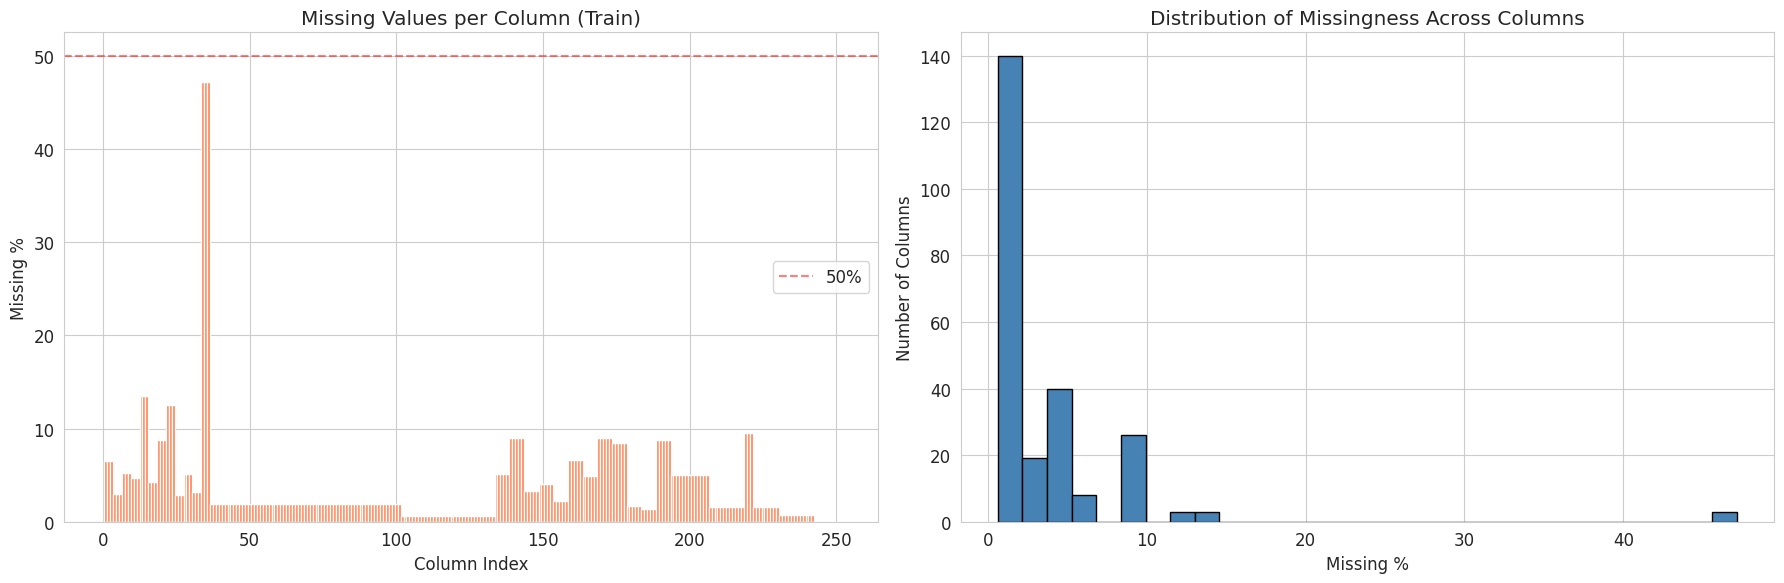


Columns with >30% missing: 3


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Missing values per column
missing_per_col = train_df.isnull().mean() * 100
axes[0].bar(range(len(missing_per_col)), missing_per_col.values, width=1.0, color='coral')
axes[0].set_xlabel('Column Index')
axes[0].set_ylabel('Missing %')
axes[0].set_title('Missing Values per Column (Train)')
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[0].legend()

# Distribution of missingness
missing_hist = missing_per_col[missing_per_col > 0]
axes[1].hist(missing_hist, bins=30, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Missing %')
axes[1].set_ylabel('Number of Columns')
axes[1].set_title('Distribution of Missingness Across Columns')

plt.tight_layout()
plt.show()

# Identify columns with too many missing values
HIGH_MISSING_THRESH = 30  # percent
high_missing_cols = missing_per_col[missing_per_col > HIGH_MISSING_THRESH].index.tolist()
print(f"\nColumns with >{HIGH_MISSING_THRESH}% missing: {len(high_missing_cols)}")

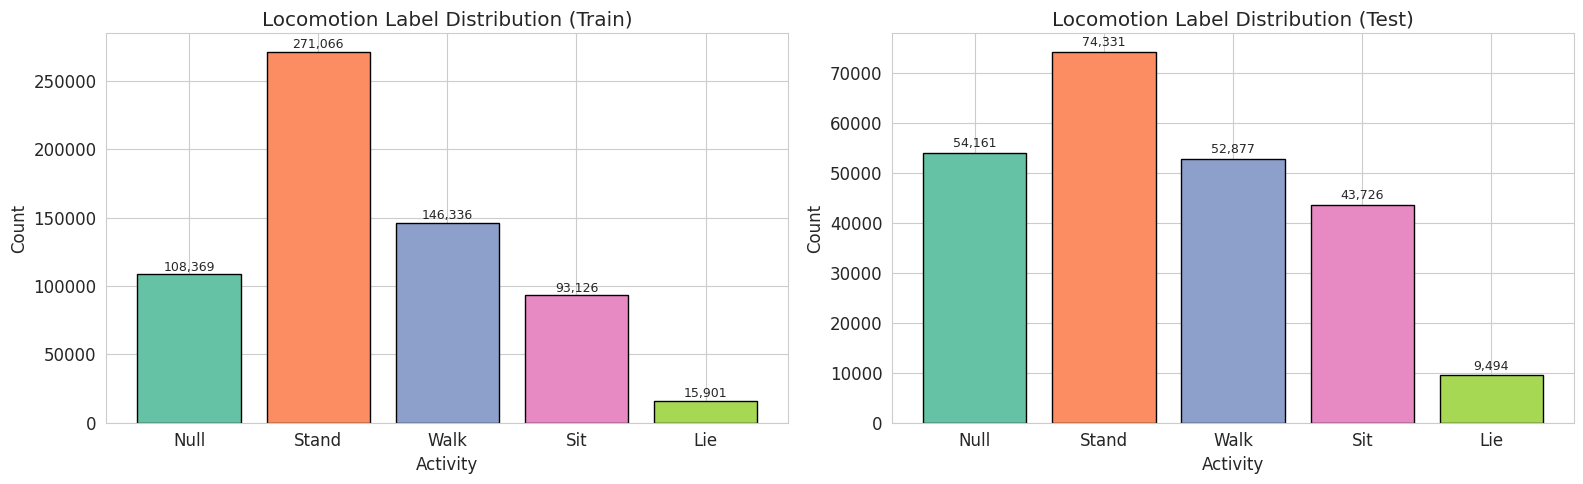


--- Locomotion Class Distribution (Train) ---
  Null       (0):  108,369 ( 17.1%)
  Stand      (1):  271,066 ( 42.7%)
  Walk       (2):  146,336 ( 23.1%)
  Sit        (4):   93,126 ( 14.7%)
  Lie        (5):   15,901 (  2.5%)


In [10]:
# Locomotion labels
LOCOMOTION_LABELS = {
    0: 'Null',
    1: 'Stand',
    2: 'Walk',
    4: 'Sit',
    5: 'Lie'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, title) in zip(axes, [(train_df, 'Train'), (test_df, 'Test')]):
    counts = df['locomotion'].value_counts().sort_index()
    labels = [LOCOMOTION_LABELS.get(k, f'Unknown({k})') for k in counts.index]
    colors = sns.color_palette('Set2', len(counts))
    
    bars = ax.bar(labels, counts.values, color=colors, edgecolor='black')
    ax.set_title(f'Locomotion Label Distribution ({title})')
    ax.set_ylabel('Count')
    ax.set_xlabel('Activity')
    
    # Add count labels on bars
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
                f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print percentages
print("\n--- Locomotion Class Distribution (Train) ---")
for label_id, name in LOCOMOTION_LABELS.items():
    count = (train_df['locomotion'] == label_id).sum()
    pct = count / len(train_df) * 100
    print(f"  {name:10s} ({label_id}): {count:>8,} ({pct:5.1f}%)")

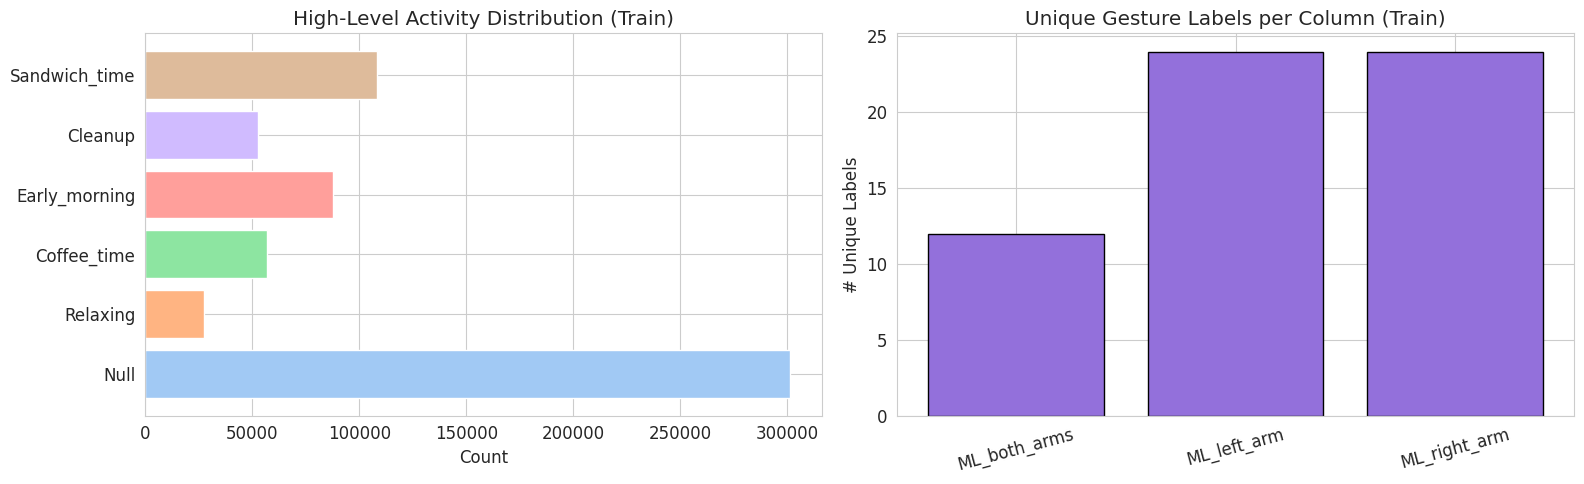


--- Mid-level gesture label counts ---

ML_both_arms:
ML_both_arms
0      538227
213     53296
205     12882
206      9289
204      9086
212      8338
209      1926
207       670
208       633
210       311
Name: count, dtype: int64

ML_left_arm:
ML_left_arm
0      538227
303     17361
320     16601
302     11167
321      6647
314      6637
304      4874
318      4793
305      4190
313      3173
Name: count, dtype: int64

ML_right_arm:
ML_right_arm
0      364023
521     52835
517     23263
516     21993
503     18613
513     14442
505     14346
512     14049
508     12668
519     11925
Name: count, dtype: int64


In [11]:
HL_ACTIVITY_LABELS = {
    0: 'Null',
    101: 'Relaxing',
    102: 'Coffee_time',
    103: 'Early_morning',
    104: 'Cleanup',
    105: 'Sandwich_time'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# High-level activity
counts_hl = train_df['HL_activity'].value_counts().sort_index()
labels_hl = [HL_ACTIVITY_LABELS.get(k, f'Unk({k})') for k in counts_hl.index]
axes[0].barh(labels_hl, counts_hl.values, color=sns.color_palette('pastel', len(counts_hl)))
axes[0].set_title('High-Level Activity Distribution (Train)')
axes[0].set_xlabel('Count')

# Mid-level gesture (right arm) — just as example
gesture_cols = ['ML_both_arms', 'ML_left_arm', 'ML_right_arm']
gesture_data = {}
for col in gesture_cols:
    unique_labels = train_df[col].dropna().unique()
    non_null = (train_df[col] != 0).sum()
    gesture_data[col] = {'unique': len(unique_labels), 'non_null': non_null}

gesture_summary = pd.DataFrame(gesture_data).T
axes[1].bar(gesture_summary.index, gesture_summary['unique'], color='mediumpurple', edgecolor='black')
axes[1].set_title('Unique Gesture Labels per Column (Train)')
axes[1].set_ylabel('# Unique Labels')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\n--- Mid-level gesture label counts ---")
for col in gesture_cols:
    print(f"\n{col}:")
    vc = train_df[col].value_counts().head(10)
    print(vc)

Number of sensor columns: 242

--- Sensor Summary Statistics ---
              mean          std           min            max          range  \
count   242.000000   242.000000    242.000000     242.000000     242.000000   
mean    186.722394   378.943655  -6336.619835   17157.884298   23494.504132   
std     890.889243   355.337747  12264.220502   52243.059455   63597.739599   
min   -1080.259448     0.004819 -98705.000000       0.000000       1.000000   
25%     -29.209445    68.103869  -5670.000000    1000.000000    2022.500000   
50%      10.288374   348.135466  -2553.000000    2800.000000    5531.500000   
75%     370.633657   511.264992   -963.750000    8081.500000   15188.250000   
max    6192.583088  1841.156075      0.000000  411567.000000  510272.000000   

       missing_pct  
count   242.000000  
mean      3.935743  
std       5.678540  
min       0.600506  
25%       1.549627  
50%       1.935576  
75%       5.020022  
max      47.163822  


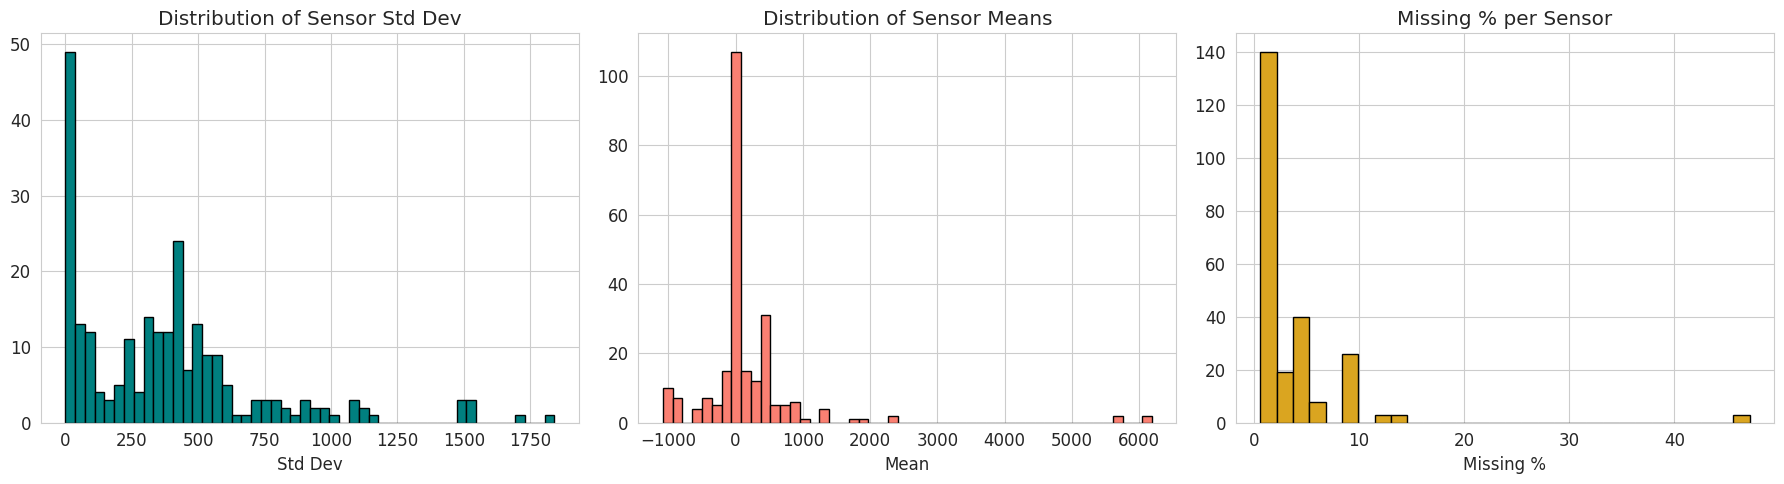

In [12]:
# Compute stats on sensor columns
sensor_col_names = [c for c in train_df.columns if c.startswith('sensor_')]
print(f"Number of sensor columns: {len(sensor_col_names)}")

sensor_stats = train_df[sensor_col_names].describe().T
sensor_stats['range'] = sensor_stats['max'] - sensor_stats['min']
sensor_stats['missing_pct'] = train_df[sensor_col_names].isnull().mean() * 100

print("\n--- Sensor Summary Statistics ---")
print(sensor_stats[['mean', 'std', 'min', 'max', 'range', 'missing_pct']].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sensor_stats['std'].dropna(), bins=50, color='teal', edgecolor='black')
axes[0].set_title('Distribution of Sensor Std Dev')
axes[0].set_xlabel('Std Dev')

axes[1].hist(sensor_stats['mean'].dropna(), bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of Sensor Means')
axes[1].set_xlabel('Mean')

axes[2].hist(sensor_stats['missing_pct'], bins=30, color='goldenrod', edgecolor='black')
axes[2].set_title('Missing % per Sensor')
axes[2].set_xlabel('Missing %')

plt.tight_layout()
plt.show()

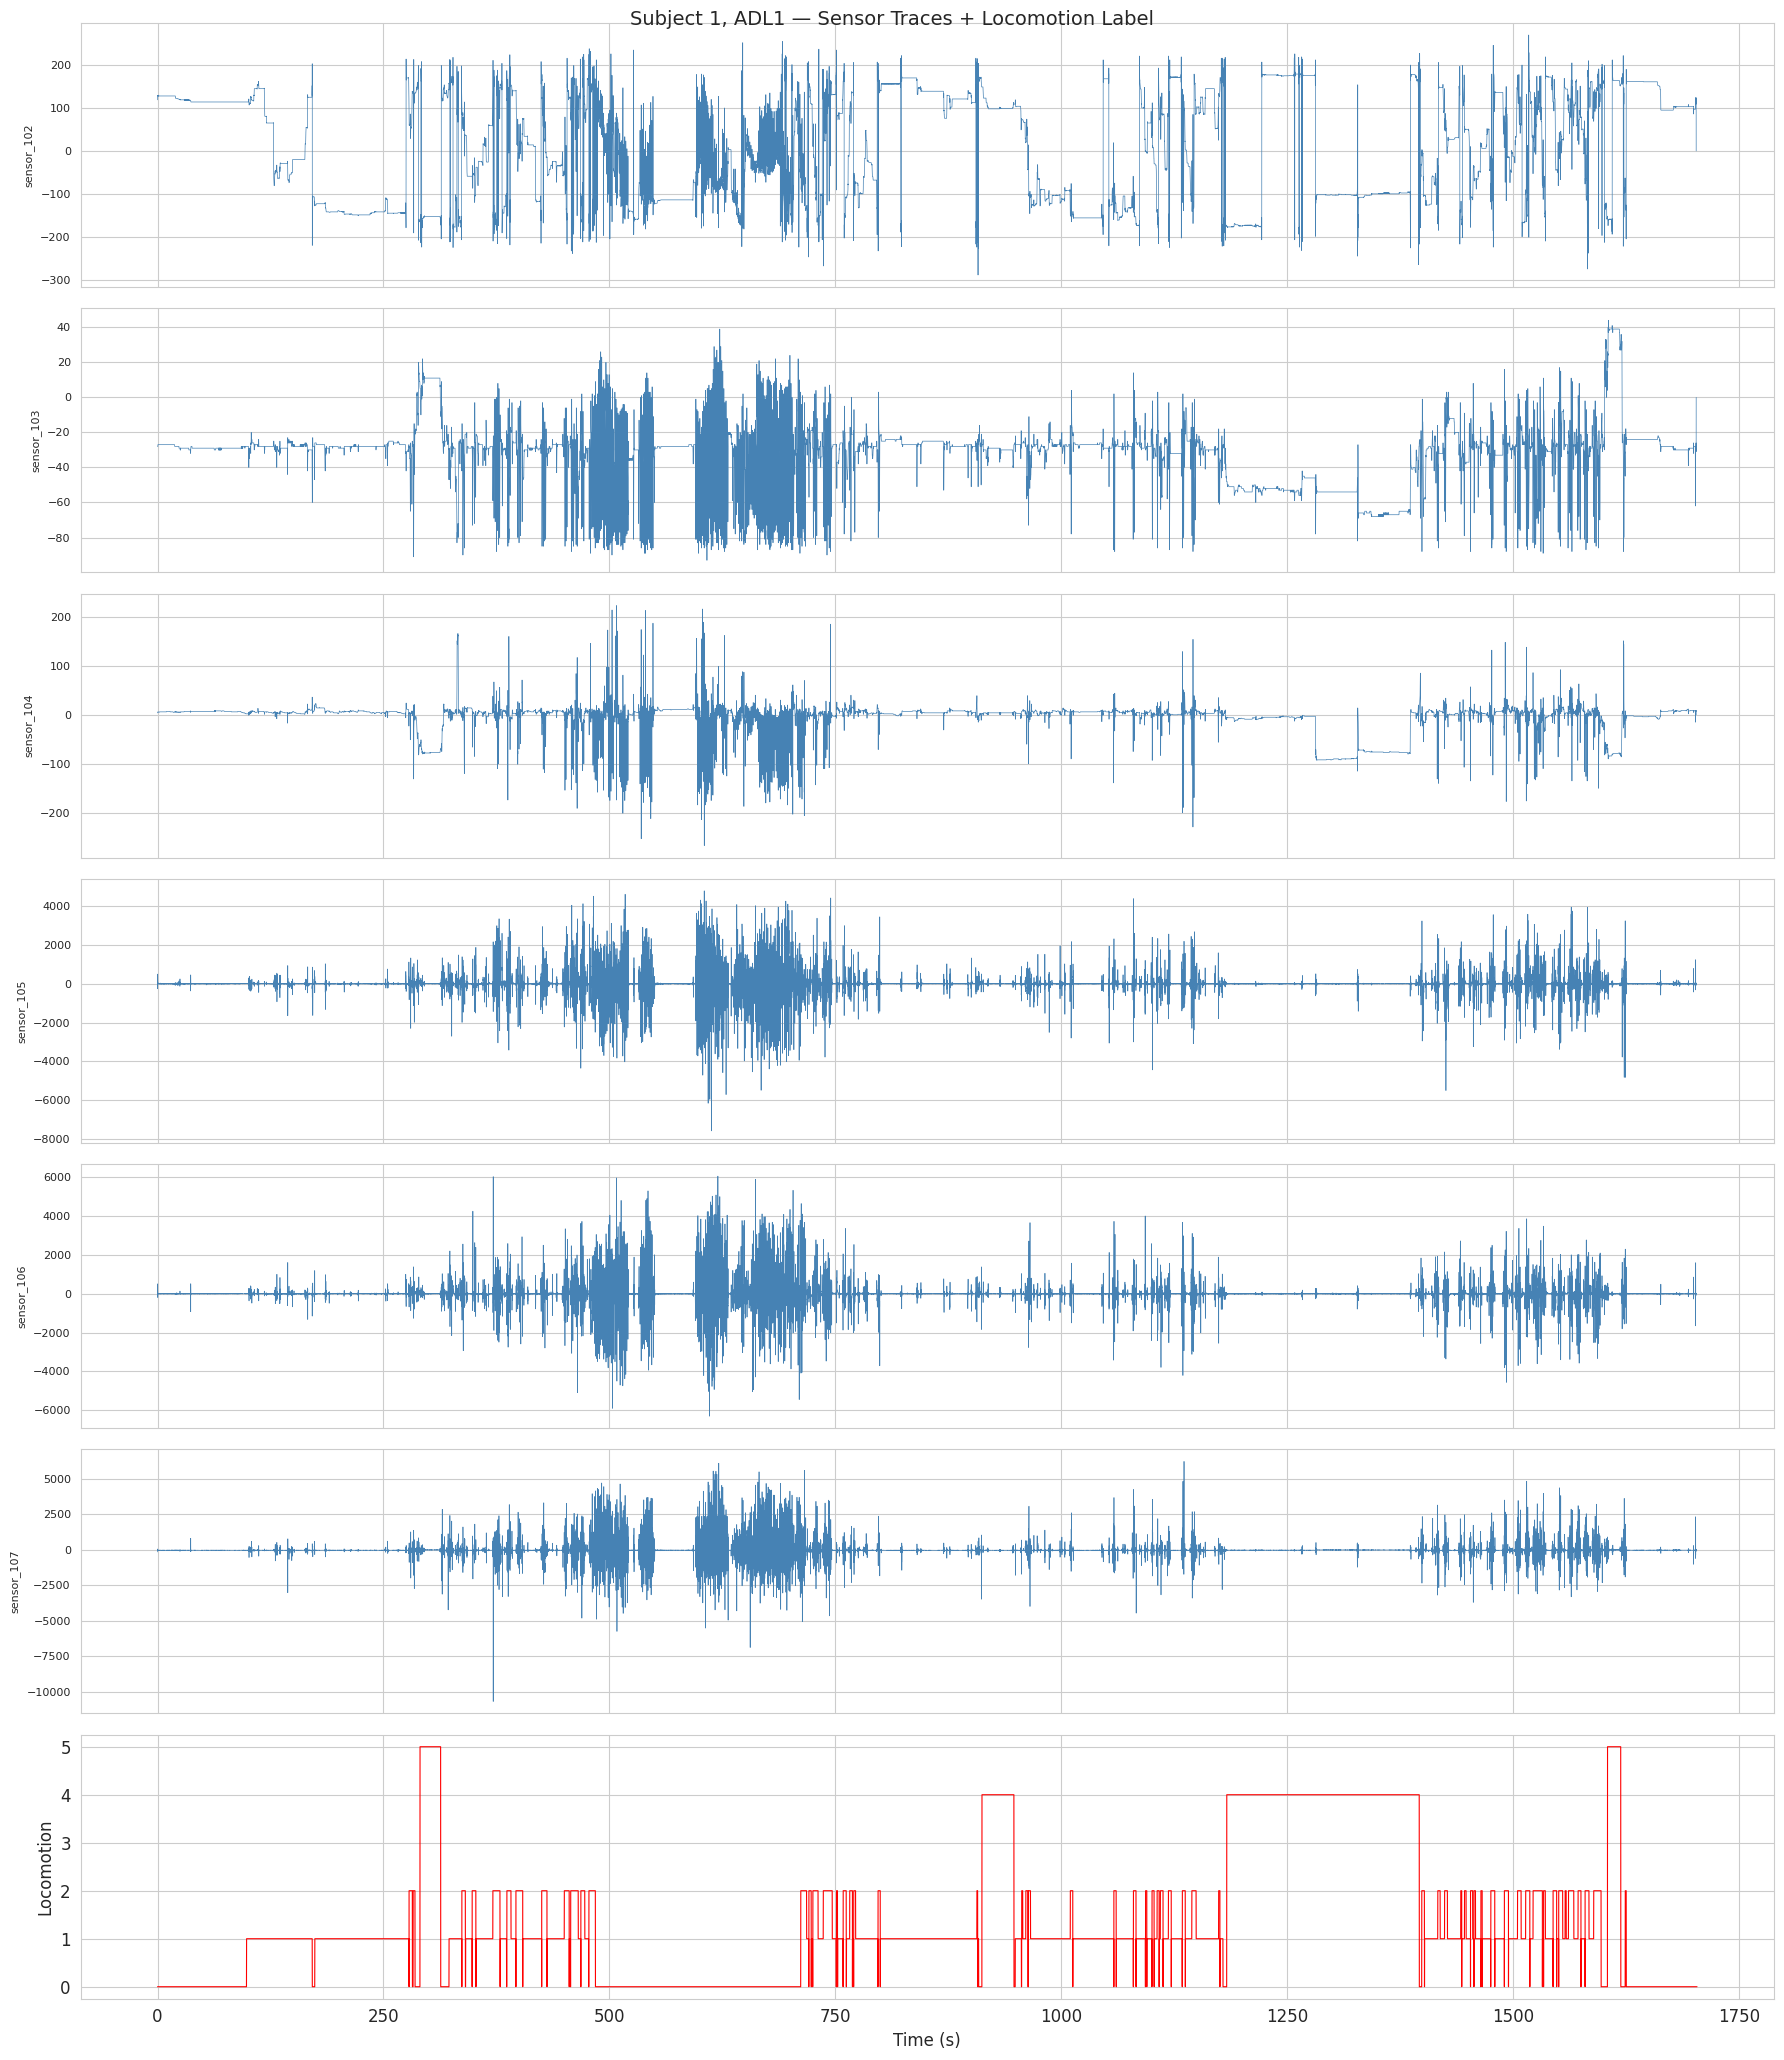

Sample duration: 1703.8 seconds (51,116 samples at 30 Hz)


In [13]:
# Plot a few sensor channels for one subject/run
sample = train_df[(train_df['subject'] == 1) & (train_df['run'] == 'ADL1')].reset_index(drop=True)

# Pick 6 sensors with low missingness
low_miss_sensors = sensor_stats[sensor_stats['missing_pct'] < 1].index[:6].tolist()

fig, axes = plt.subplots(len(low_miss_sensors) + 1, 1, figsize=(18, 3 * (len(low_miss_sensors) + 1)), 
                         sharex=True)

# Time axis (in seconds, 30 Hz sampling rate)
time_axis = np.arange(len(sample)) / 30.0

for i, col in enumerate(low_miss_sensors):
    axes[i].plot(time_axis, sample[col].values, linewidth=0.5, color='steelblue')
    axes[i].set_ylabel(col, fontsize=8)
    axes[i].tick_params(labelsize=8)

# Plot locomotion label
axes[-1].plot(time_axis, sample['locomotion'].values, linewidth=0.8, color='red')
axes[-1].set_ylabel('Locomotion')
axes[-1].set_xlabel('Time (s)')

fig.suptitle('Subject 1, ADL1 — Sensor Traces + Locomotion Label', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Sample duration: {time_axis[-1]:.1f} seconds ({len(sample):,} samples at 30 Hz)")

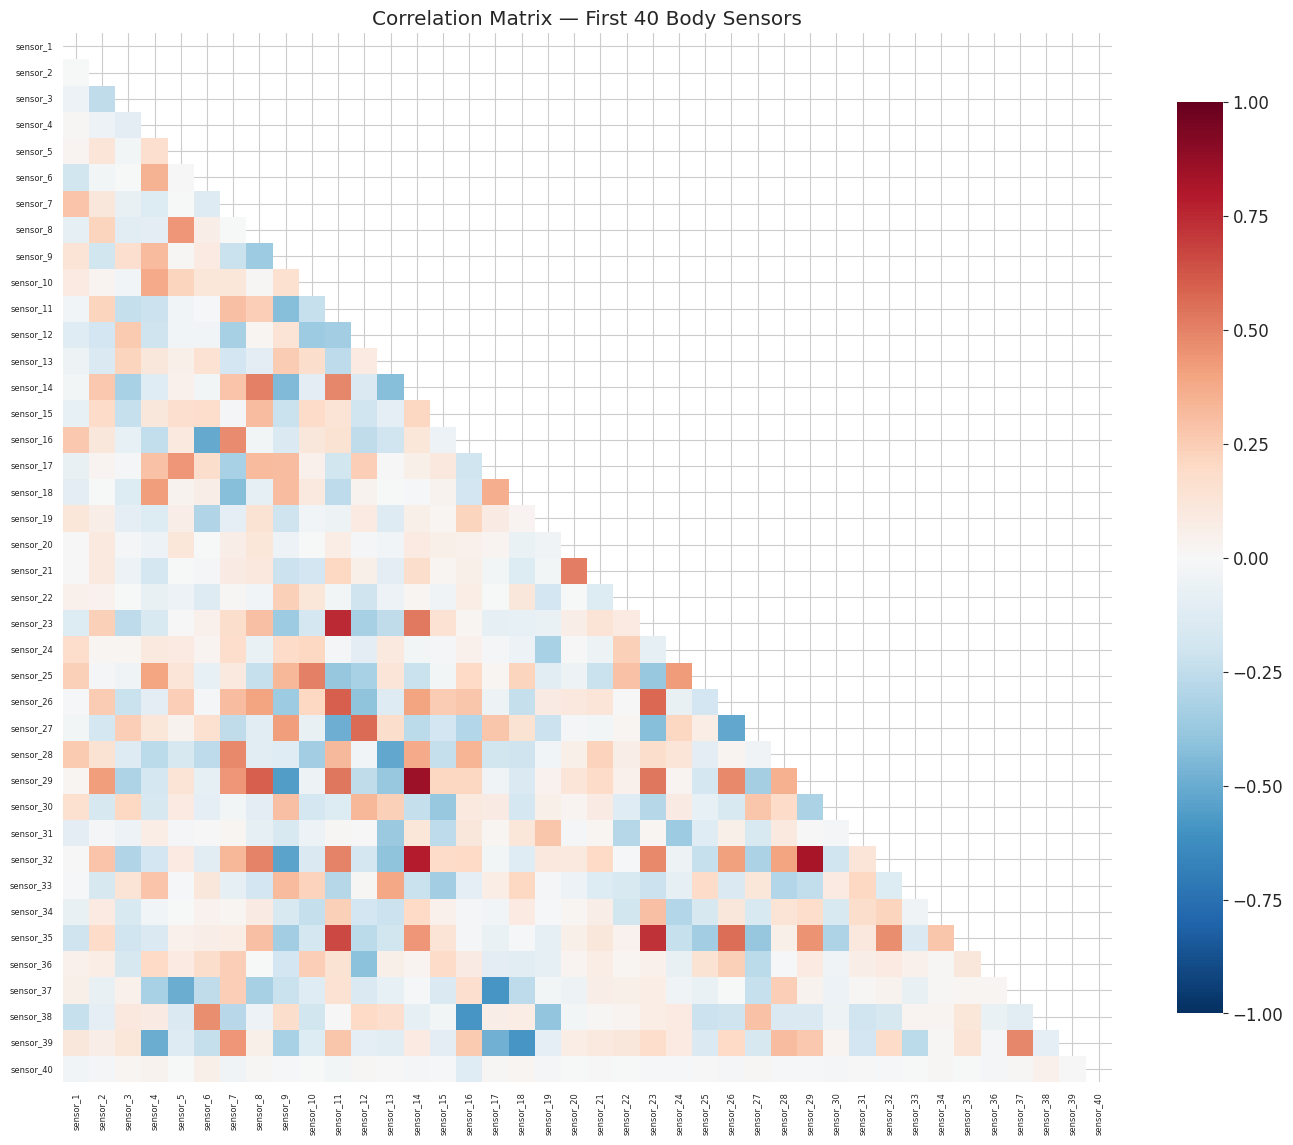

In [14]:
# Correlation among first 40 body sensors (for readability)
subset_sensors = sensor_col_names[:40]
corr_matrix = train_df[subset_sensors].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix — First 40 Body Sensors')
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_492076/2699440613.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='locomotion_name', y=col, ax=ax,
/tmp/ipykernel_492076/2699440613.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='locomotion_name', y=col, ax=ax,
/tmp/ipykernel_492076/2699440613.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='locomotion_name', y=col, ax=ax,
/tmp/ipykernel_492076/2699440613.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

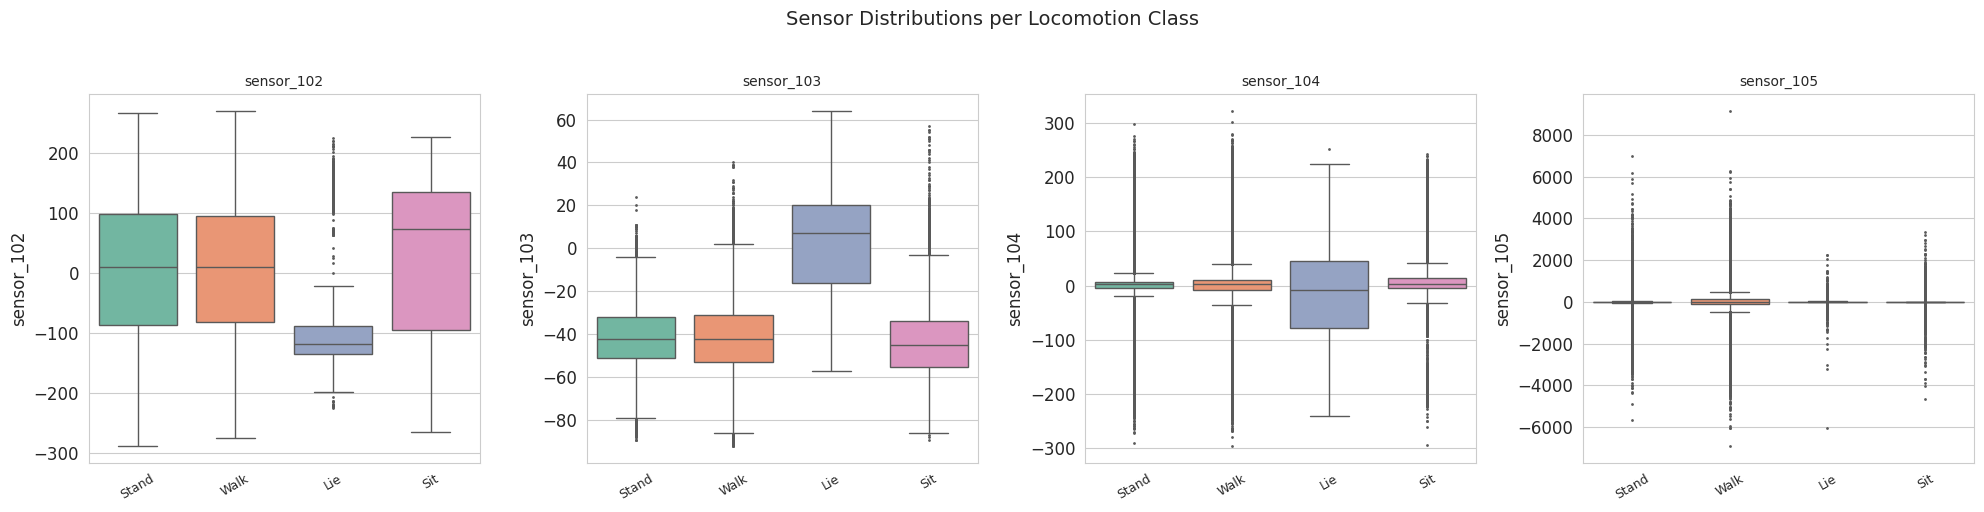

In [15]:
# Show how sensor values differ across locomotion classes
# Pick 4 informative sensors
plot_sensors = low_miss_sensors[:4]

fig, axes = plt.subplots(1, len(plot_sensors), figsize=(5 * len(plot_sensors), 5))

# Only non-null locomotion labels
plot_df = train_df[train_df['locomotion'] != 0].copy()
plot_df['locomotion_name'] = plot_df['locomotion'].map(LOCOMOTION_LABELS)

for ax, col in zip(axes, plot_sensors):
    sns.boxplot(data=plot_df, x='locomotion_name', y=col, ax=ax, 
                palette='Set2', fliersize=1)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=9)

fig.suptitle('Sensor Distributions per Locomotion Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

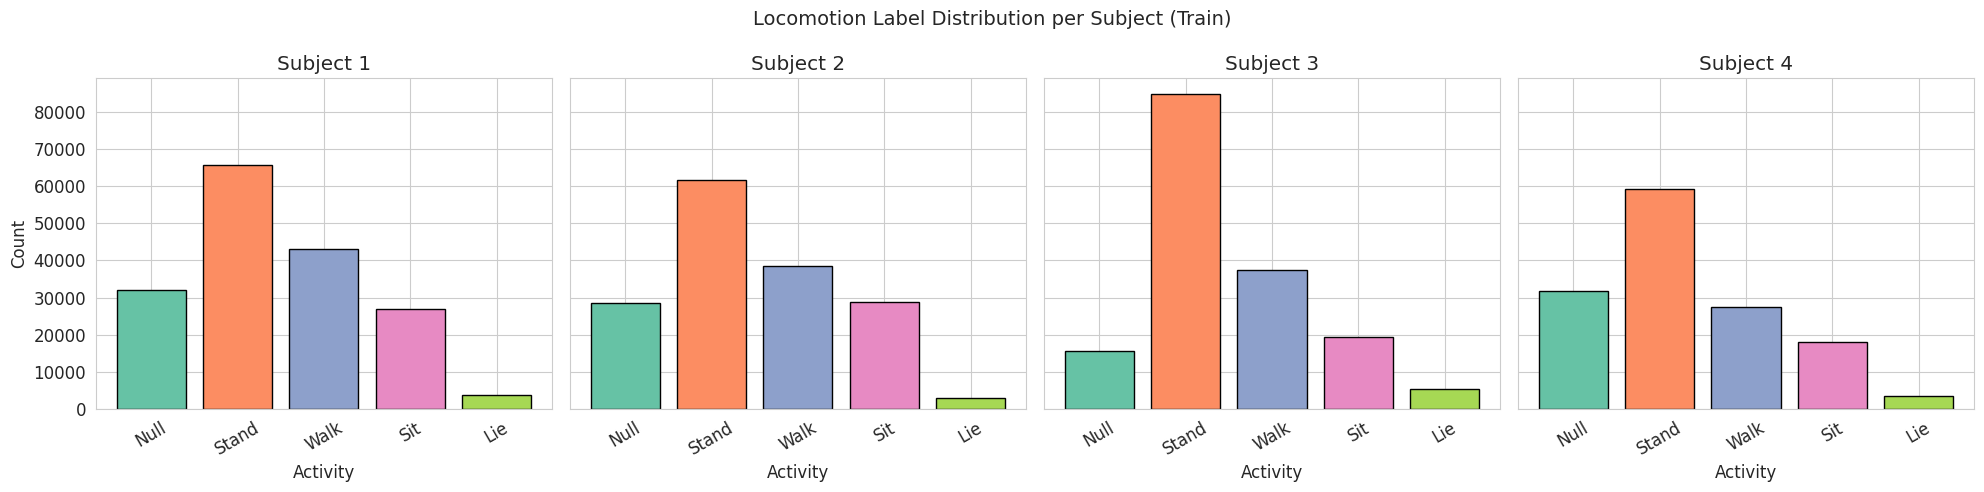

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, subj in zip(axes, SUBJECTS):
    subj_data = train_df[train_df['subject'] == subj]
    counts = subj_data['locomotion'].value_counts().sort_index()
    labels = [LOCOMOTION_LABELS.get(k, f'{k}') for k in counts.index]
    ax.bar(labels, counts.values, color=sns.color_palette('Set2', len(counts)), edgecolor='black')
    ax.set_title(f'Subject {subj}')
    ax.set_xlabel('Activity')
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Count')
fig.suptitle('Locomotion Label Distribution per Subject (Train)', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
"""
TASK CHOICE: Locomotion Recognition (4-class, ignoring Null)
  Classes: Stand(1), Walk(2), Sit(4), Lie(5)
  
FEATURE CHOICE: Body-worn sensors only (cols 1-134) — 134 features
  This follows the "Motion Jacket" configuration from the benchmark.
  
PREPROCESSING PLAN:
  1. Select body-worn sensor columns
  2. Handle missing values (forward-fill, then backward-fill, then zero-fill)
  3. Remove columns that are entirely NaN or have >50% missing
  4. Remove low-variance columns
  5. Standardize (z-score using train stats)
  6. Create sliding windows -> (batch, seq_len, features)
  7. Split: train (ADL1-3 + Drill), val (hold out ADL3 from S1-S2), test (ADL4-5)
"""

TASK = 'locomotion'
TARGET_COL = 'locomotion'

# Map to 0-based contiguous labels (ignore Null=0)
LABEL_MAP = {1: 0, 2: 1, 4: 2, 5: 3}  # Stand=0, Walk=1, Sit=2, Lie=3
NUM_CLASSES = len(LABEL_MAP)
LABEL_NAMES = ['Stand', 'Walk', 'Sit', 'Lie']

BODY_SENSOR_NAMES = [f'sensor_{i}' for i in range(1, 135)]

print(f"Task: {TASK}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Label mapping: {LABEL_MAP}")
print(f"Initial feature set: {len(BODY_SENSOR_NAMES)} body-worn sensors")

Task: locomotion
Number of classes: 4
Label mapping: {1: 0, 2: 1, 4: 2, 5: 3}
Initial feature set: 134 body-worn sensors


In [18]:
def handle_missing_values(df, sensor_cols, max_missing_pct=50.0):
    """
    Handle missing values:
    1. Drop columns with > max_missing_pct% missing
    2. Forward-fill → backward-fill → zero-fill the rest
    """
    df = df.copy()
    
    # Check missingness per column
    missing_pct = df[sensor_cols].isnull().mean() * 100
    cols_to_drop = missing_pct[missing_pct > max_missing_pct].index.tolist()
    cols_to_keep = [c for c in sensor_cols if c not in cols_to_drop]
    
    print(f"Columns with >{max_missing_pct}% missing → dropped: {len(cols_to_drop)}")
    print(f"Keeping {len(cols_to_keep)} sensor columns")
    
    # Fill missing: ffill → bfill → 0
    df[cols_to_keep] = df[cols_to_keep].ffill().bfill().fillna(0.0)
    
    # Verify no NaN left
    assert df[cols_to_keep].isnull().sum().sum() == 0, "Still have NaN after filling!"
    
    return df, cols_to_keep, cols_to_drop

train_filled, kept_sensors, dropped_sensors = handle_missing_values(
    train_df, BODY_SENSOR_NAMES, max_missing_pct=50.0
)
test_filled, _, _ = handle_missing_values(
    test_df, BODY_SENSOR_NAMES, max_missing_pct=50.0
)

# Use only the intersection of kept sensors
kept_sensors_test = [c for c in kept_sensors if c in test_filled.columns and 
                     test_filled[c].isnull().sum() == 0]
kept_sensors = sorted(set(kept_sensors) & set(kept_sensors_test))

print(f"\nFinal sensor columns after alignment: {len(kept_sensors)}")
if dropped_sensors:
    print(f"Dropped sensors: {dropped_sensors}")

Columns with >50.0% missing → dropped: 0
Keeping 134 sensor columns
Columns with >50.0% missing → dropped: 0
Keeping 134 sensor columns

Final sensor columns after alignment: 134


In [19]:
def remove_low_variance_features(train_df, sensor_cols, threshold=0.01):
    """Remove features with std < threshold in train set"""
    std_vals = train_df[sensor_cols].std()
    low_var = std_vals[std_vals <= threshold].index.tolist()
    kept = [c for c in sensor_cols if c not in low_var]
    
    print(f"Removed {len(low_var)} low-variance features (std ≤ {threshold})")
    if low_var:
        print(f"  Removed: {low_var[:10]}{'...' if len(low_var) > 10 else ''}")
    print(f"Kept {len(kept)} features")
    return kept, low_var

feature_cols, low_var_removed = remove_low_variance_features(
    train_filled, kept_sensors, threshold=0.01
)

print(f"\n✅ Feature dimension: {len(feature_cols)}")

Removed 0 low-variance features (std ≤ 0.01)
Kept 134 features

✅ Feature dimension: 134


In [20]:
def filter_and_map_labels(df, target_col, label_map):
    """Remove Null class and map labels to contiguous 0-based integers"""
    df = df.copy()
    # Keep only rows with valid labels
    valid_mask = df[target_col].isin(label_map.keys())
    df = df[valid_mask].reset_index(drop=True)
    df['label'] = df[target_col].map(label_map).astype(int)
    return df

train_labeled = filter_and_map_labels(train_filled, TARGET_COL, LABEL_MAP)
test_labeled = filter_and_map_labels(test_filled, TARGET_COL, LABEL_MAP)

print(f"Train samples (after removing Null): {len(train_labeled):,}")
print(f"Test samples (after removing Null):  {len(test_labeled):,}")

print(f"\nTrain label distribution:")
for label_id, name in enumerate(LABEL_NAMES):
    count = (train_labeled['label'] == label_id).sum()
    print(f"  {name}: {count:,} ({count/len(train_labeled)*100:.1f}%)")

print(f"\nTest label distribution:")
for label_id, name in enumerate(LABEL_NAMES):
    count = (test_labeled['label'] == label_id).sum()
    print(f"  {name}: {count:,} ({count/len(test_labeled)*100:.1f}%)")

Train samples (after removing Null): 526,429
Test samples (after removing Null):  180,428

Train label distribution:
  Stand: 271,066 (51.5%)
  Walk: 146,336 (27.8%)
  Sit: 93,126 (17.7%)
  Lie: 15,901 (3.0%)

Test label distribution:
  Stand: 74,331 (41.2%)
  Walk: 52,877 (29.3%)
  Sit: 43,726 (24.2%)
  Lie: 9,494 (5.3%)


In [21]:
"""
Split strategy:
  Train: S1-S4 {ADL1, ADL2, Drill}
  Val:   S1-S4 {ADL3}  (held out from training runs)
  Test:  S1-S4 {ADL4, ADL5}
"""

VAL_RUNS = ['ADL3']
ACTUAL_TRAIN_RUNS = ['ADL1', 'ADL2', 'Drill']

train_split = train_labeled[train_labeled['run'].isin(ACTUAL_TRAIN_RUNS)].reset_index(drop=True)
val_split = train_labeled[train_labeled['run'].isin(VAL_RUNS)].reset_index(drop=True)
test_split = test_labeled.reset_index(drop=True)

print(f"Train:  {len(train_split):,} samples")
print(f"Val:    {len(val_split):,} samples")
print(f"Test:   {len(test_split):,} samples")

# Label distributions per split
for name, split_df in [('Train', train_split), ('Val', val_split), ('Test', test_split)]:
    counts = split_df['label'].value_counts().sort_index()
    total = len(split_df)
    dist = ', '.join([f"{LABEL_NAMES[i]}:{c}({c/total*100:.1f}%)" for i, c in counts.items()])
    print(f"\n{name}: {dist}")

Train:  435,519 samples
Val:    90,910 samples
Test:   180,428 samples

Train: Stand:230215(52.9%), Walk:125579(28.8%), Sit:68657(15.8%), Lie:11068(2.5%)

Val: Stand:40851(44.9%), Walk:20757(22.8%), Sit:24469(26.9%), Lie:4833(5.3%)

Test: Stand:74331(41.2%), Walk:52877(29.3%), Sit:43726(24.2%), Lie:9494(5.3%)


In [22]:
# Normalization:
def standardize_features(train_df, val_df, test_df, feature_cols):
    """
    Z-score normalization using TRAIN statistics only.
    Returns normalized DataFrames and the stats for denormalization.
    """
    mean = train_df[feature_cols].mean()
    std = train_df[feature_cols].std().replace(0.0, 1.0)  # avoid div by zero
    
    def normalize(df):
        out = df.copy()
        out[feature_cols] = (df[feature_cols] - mean) / std
        return out
    
    train_norm = normalize(train_df)
    val_norm = normalize(val_df)
    test_norm = normalize(test_df)
    
    norm_stats = {
        'mean': mean,
        'std': std
    }
    
    return train_norm, val_norm, test_norm, norm_stats

train_norm, val_norm, test_norm, norm_stats = standardize_features(
    train_split, val_split, test_split, feature_cols
)

# Verify
print("Normalization complete.")
print(f"Train feature mean (should be ~0): {train_norm[feature_cols].mean().mean():.6f}")
print(f"Train feature std  (should be ~1): {train_norm[feature_cols].std().mean():.6f}")
print(f"Val feature mean:   {val_norm[feature_cols].mean().mean():.6f}")
print(f"Test feature mean:  {test_norm[feature_cols].mean().mean():.6f}")

Normalization complete.
Train feature mean (should be ~0): -0.000000
Train feature std  (should be ~1): 1.000000
Val feature mean:   -0.024348
Test feature mean:  -0.025882


In [23]:
def denormalize(data, norm_stats, feature_cols=None):
    """
    Inverse z-score transform.
    
    Args:
        data: numpy array of shape (..., D) or DataFrame
        norm_stats: dict with 'mean' and 'std' (pandas Series or numpy arrays)
        feature_cols: optional list of column names (for DataFrame input)
    
    Returns:
        Denormalized data in same format as input
    """
    mean = norm_stats['mean']
    std = norm_stats['std']
    
    if isinstance(data, pd.DataFrame):
        out = data.copy()
        cols = feature_cols or mean.index.tolist()
        out[cols] = data[cols] * std[cols].values + mean[cols].values
        return out
    elif isinstance(data, np.ndarray):
        mean_np = mean.values if hasattr(mean, 'values') else np.array(mean)
        std_np = std.values if hasattr(std, 'values') else np.array(std)
        return data * std_np + mean_np
    elif isinstance(data, torch.Tensor):
        mean_t = torch.tensor(mean.values, dtype=data.dtype, device=data.device)
        std_t = torch.tensor(std.values, dtype=data.dtype, device=data.device)
        return data * std_t + mean_t
    else:
        raise TypeError(f"Unsupported type: {type(data)}")

# Quick test
sample_row = train_norm[feature_cols].iloc[0].values
restored = denormalize(sample_row, norm_stats)
original = train_split[feature_cols].iloc[0].values
assert np.allclose(restored, original, atol=1e-5), "Denormalization failed!"
print("✅ Denormalization verified.")

✅ Denormalization verified.


In [24]:
class OpportunityDataset(Dataset):
    """
    Sliding-window dataset for Opportunity UCI.
    
    Produces:
        X: (seq_len, num_features) float32
        y: int64 scalar — majority label in the window
    """
    
    def __init__(self, df, feature_cols, label_col='label', 
                 seq_len=30, step=15, label_strategy='last'):
        """
        Args:
            df: DataFrame with normalized features and 'label' column.
                Must also have 'subject' and 'run' for segment boundaries.
            feature_cols: list of feature column names
            label_col: column name for the target label
            seq_len: sliding window length
            step: stride between windows
            label_strategy: 'last' (use last label) or 'majority' (majority vote)
        """
        self.seq_len = seq_len
        self.feature_cols = feature_cols
        self.label_col = label_col
        self.label_strategy = label_strategy
        
        self.sequences = []
        self.labels = []
        
        # Create windows per (subject, run) to avoid cross-segment windows
        for (subj, run), group in df.groupby(['subject', 'run']):
            features = group[feature_cols].values.astype(np.float32)
            labels = group[label_col].values.astype(np.int64)
            
            for start in range(0, len(features) - seq_len + 1, step):
                window_features = features[start:start + seq_len]
                window_labels = labels[start:start + seq_len]
                
                if label_strategy == 'last':
                    label = window_labels[-1]
                elif label_strategy == 'majority':
                    label = int(np.bincount(window_labels).argmax())
                else:
                    raise ValueError(f"Unknown label_strategy: {label_strategy}")
                
                self.sequences.append(window_features)
                self.labels.append(label)
        
        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)
        
        print(f"Created {len(self.sequences)} windows "
              f"(seq_len={seq_len}, step={step}, strategy={label_strategy})")
        print(f"  Shape: X={self.sequences.shape}, y={self.labels.shape}")
        print(f"  Class distribution: {dict(Counter(self.labels.tolist()))}")
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        X = torch.from_numpy(self.sequences[idx])   # (seq_len, features)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return X, y

In [25]:
# Hyperparameters
SEQUENCE_LENGTH = 30   # 30 time steps = 1 second at 30 Hz
STEP_TRAIN = 15        # 50% overlap for training
STEP_EVAL = 15         # same for val/test
BATCH_SIZE = 64
LABEL_STRATEGY = 'last'

print("=" * 70)
print("Creating Datasets")
print("=" * 70)

print("\n--- Train ---")
train_dataset = OpportunityDataset(
    train_norm, feature_cols, seq_len=SEQUENCE_LENGTH, 
    step=STEP_TRAIN, label_strategy=LABEL_STRATEGY
)

print("\n--- Val ---")
val_dataset = OpportunityDataset(
    val_norm, feature_cols, seq_len=SEQUENCE_LENGTH, 
    step=STEP_EVAL, label_strategy=LABEL_STRATEGY
)

print("\n--- Test ---")
test_dataset = OpportunityDataset(
    test_norm, feature_cols, seq_len=SEQUENCE_LENGTH, 
    step=STEP_EVAL, label_strategy=LABEL_STRATEGY
)

# DataLoaders
g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=0, generator=g, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n{'='*70}")
print(f"DataLoader Summary")
print(f"{'='*70}")
print(f"  Train: {len(train_loader)} batches × {BATCH_SIZE} = ~{len(train_dataset)} samples")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")

Creating Datasets

--- Train ---
Created 29017 windows (seq_len=30, step=15, strategy=last)
  Shape: X=(29017, 30, 134), y=(29017,)
  Class distribution: {0: 15315, 1: 8388, 3: 738, 2: 4576}

--- Val ---
Created 6055 windows (seq_len=30, step=15, strategy=last)
  Shape: X=(6055, 30, 134), y=(6055,)
  Class distribution: {0: 2729, 1: 1372, 3: 322, 2: 1632}

--- Test ---
Created 12018 windows (seq_len=30, step=15, strategy=last)
  Shape: X=(12018, 30, 134), y=(12018,)
  Class distribution: {0: 4955, 1: 3515, 3: 634, 2: 2914}

DataLoader Summary
  Train: 453 batches × 64 = ~29017 samples
  Val:   95 batches
  Test:  188 batches


In [26]:
# Verify shapes: (batch, seq_len, features)
X_batch, y_batch = next(iter(train_loader))
print(f"X batch shape: {X_batch.shape}  → (batch={X_batch.shape[0]}, seq={X_batch.shape[1]}, features={X_batch.shape[2]})")
print(f"y batch shape: {y_batch.shape}  → (batch={y_batch.shape[0]},)")
print(f"X dtype: {X_batch.dtype}")
print(f"y dtype: {y_batch.dtype}")
print(f"y unique in batch: {y_batch.unique().tolist()}")

# Quick stats
print(f"\nX mean: {X_batch.mean():.4f}")
print(f"X std:  {X_batch.std():.4f}")
print(f"X min:  {X_batch.min():.4f}")
print(f"X max:  {X_batch.max():.4f}")

assert X_batch.shape == (BATCH_SIZE, SEQUENCE_LENGTH, len(feature_cols)), "Shape mismatch!"
print(f"\n✅ Shape verified: ({BATCH_SIZE}, {SEQUENCE_LENGTH}, {len(feature_cols)})")

X batch shape: torch.Size([64, 30, 134])  → (batch=64, seq=30, features=134)
y batch shape: torch.Size([64])  → (batch=64,)
X dtype: torch.float32
y dtype: torch.int64
y unique in batch: [0, 1, 2, 3]

X mean: -0.0076
X std:  1.0048
X min:  -14.1501
X max:  8.7981

✅ Shape verified: (64, 30, 134)


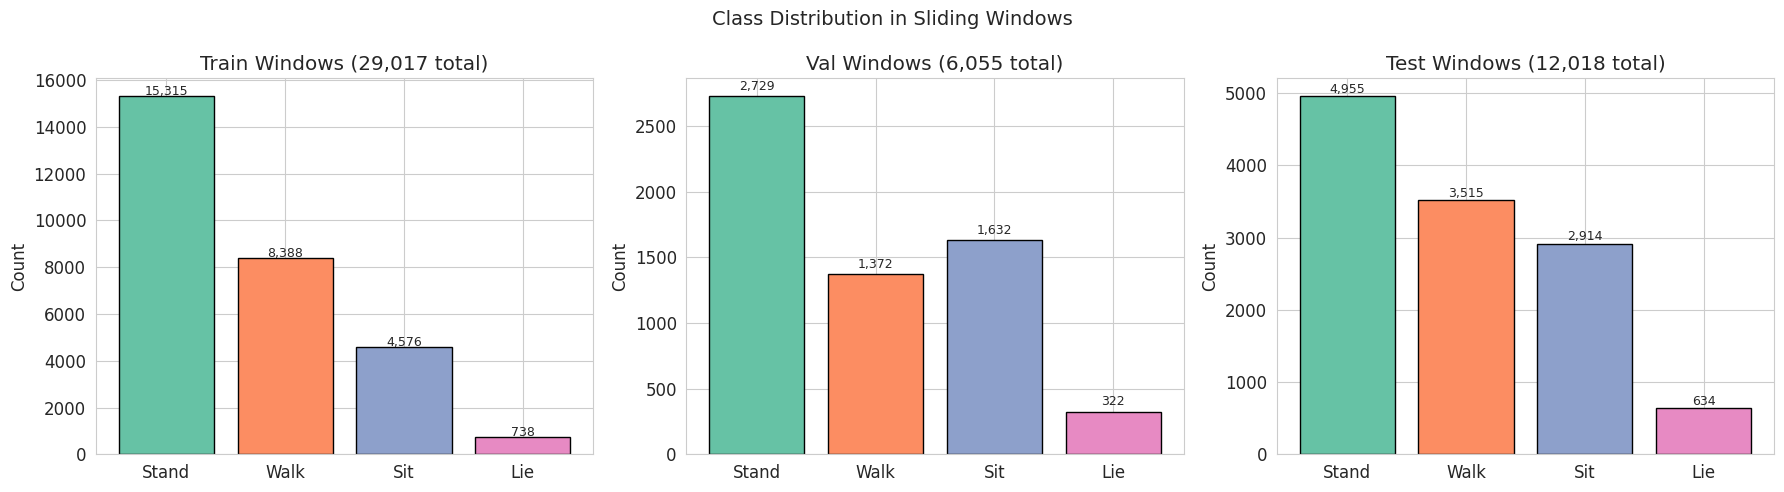

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, dataset) in zip(axes, [('Train', train_dataset), ('Val', val_dataset), ('Test', test_dataset)]):
    counts = Counter(dataset.labels.tolist())
    sorted_counts = sorted(counts.items())
    labels = [LABEL_NAMES[k] for k, _ in sorted_counts]
    values = [v for _, v in sorted_counts]
    colors = sns.color_palette('Set2', NUM_CLASSES)
    
    bars = ax.bar(labels, values, color=colors, edgecolor='black')
    ax.set_title(f'{name} Windows ({sum(values):,} total)')
    ax.set_ylabel('Count')
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', fontsize=9)

plt.suptitle('Class Distribution in Sliding Windows', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
import json

# Save preprocessing config for reproducibility
preprocess_config = {
    'task': TASK,
    'num_classes': NUM_CLASSES,
    'label_map': {str(k): v for k, v in LABEL_MAP.items()},  # JSON needs str keys
    'label_names': LABEL_NAMES,
    'feature_cols': feature_cols,
    'num_features': len(feature_cols),
    'sequence_length': SEQUENCE_LENGTH,
    'step_train': STEP_TRAIN,
    'step_eval': STEP_EVAL,
    'batch_size': BATCH_SIZE,
    'label_strategy': LABEL_STRATEGY,
    'train_runs': ACTUAL_TRAIN_RUNS,
    'val_runs': VAL_RUNS,
    'test_runs': TEST_RUNS,
    'dropped_sensors': dropped_sensors,
    'low_var_removed': low_var_removed,
    'normalization': {
        'mean': norm_stats['mean'].to_dict(),
        'std': norm_stats['std'].to_dict(),
    },
    'train_samples': len(train_dataset),
    'val_samples': len(val_dataset),
    'test_samples': len(test_dataset),
}

save_dir = project_root / "outputs" / "oportunity_uci"
save_dir.mkdir(parents=True, exist_ok=True)

preprocess_path = save_dir / "preprocess_config.json"
with open(preprocess_path, 'w') as f:
    json.dump(preprocess_config, f, indent=2)

print(f"✅ Saved preprocessing config to {preprocess_path}")
print(f"\n--- Summary ---")
print(f"  Features:   {len(feature_cols)}")
print(f"  Seq length: {SEQUENCE_LENGTH}")
print(f"  Classes:    {NUM_CLASSES} ({LABEL_NAMES})")
print(f"  Train:      {len(train_dataset):,} windows")
print(f"  Val:        {len(val_dataset):,} windows")
print(f"  Test:       {len(test_dataset):,} windows")
print(f"\n  Ready for LSTM / GRU / Transformer training!")
print(f"  Batch shape: ({BATCH_SIZE}, {SEQUENCE_LENGTH}, {len(feature_cols)})")

✅ Saved preprocessing config to /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/oportunity_uci/preprocess_config.json

--- Summary ---
  Features:   134
  Seq length: 30
  Classes:    4 (['Stand', 'Walk', 'Sit', 'Lie'])
  Train:      29,017 windows
  Val:        6,055 windows
  Test:       12,018 windows

  Ready for LSTM / GRU / Transformer training!
  Batch shape: (64, 30, 134)


In [29]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights for handling imbalance
class_weights = compute_class_weight(
    'balanced', 
    classes=np.arange(NUM_CLASSES), 
    y=train_dataset.labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Class weights (for CrossEntropyLoss):")
for i, (name, w) in enumerate(zip(LABEL_NAMES, class_weights)):
    print(f"  {name}: {w:.4f}")

print(f"\nTensor: {class_weights_tensor}")
print(f"\nUsage: criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))")

Class weights (for CrossEntropyLoss):
  Stand: 0.4737
  Walk: 0.8648
  Sit: 1.5853
  Lie: 9.8296

Tensor: tensor([0.4737, 0.8648, 1.5853, 9.8296])

Usage: criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))


In [31]:
import torch.nn as nn

# Quick smoke test: verify a simple LSTM can process the data
class QuickLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
device = torch.device('cpu')

# Test forward pass
model_test = QuickLSTM(len(feature_cols), 64, NUM_CLASSES).to(device)
X_test, y_test = next(iter(train_loader))
X_test = X_test.to(device)

with torch.no_grad():
    out = model_test(X_test)

print(f"Input:  {X_test.shape}")
print(f"Output: {out.shape}  (batch, num_classes)")
print(f"Logits sample: {out[0].cpu().numpy()}")
print(f"\n✅ Smoke test passed! Data pipeline is ready for training.")

del model_test  # cleanup

Device: cuda
Input:  torch.Size([64, 30, 134])
Output: torch.Size([64, 4])  (batch, num_classes)
Logits sample: [ 0.00725716 -0.20096305  0.17523377  0.00808991]

✅ Smoke test passed! Data pipeline is ready for training.
